# Show that m must be negative

Currently, this does one plot per group, using g1 and g11 fixed input from user, with the average start size of that group.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.formula import api as smf
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error
from estimator import Estimator
from src import pyxfunc

## User defined parameters

In [2]:
config_file = "config_files/config_km.json"
growth_data_file = "data/growth_data_df.csv"

figure_save_path = "figures/" # Set to None to not save figures

g1 = 0.171
g11 = 0.141

k_min = -0.5
k_max = 0.5
k_inc = 0.01
m_min = -0.5
m_max = 0.5
m_inc = 0.01

## Setup

In [17]:
groups = ["Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)"]
growth_df = pd.read_csv(growth_data_file)
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
es = Estimator(config_file)

k_list = [round(k_min+k_inc*i, 2) for i in range(round((k_max-k_min)/k_inc+1))]
m_list = [round(m_min+m_inc*i, 2) for i in range(round((m_max-m_min)/m_inc+1))]

In [18]:
def get_init(group, size):
    if "B2" in group: return [0.8*size, 0.2*size, 0]
    if "B3" in group: return [0.5*size, 0.5*size, 0]
    if "B4" in group: return [0.2*size, 0.8*size, 0]

## Generate results

In [19]:
results = []
for group in groups:
    avg_init_size = growth_df[(growth_df["group"] == group) & (growth_df["day"]==7)]["size"].mean()
    end_time = growth_df[(growth_df["group"] == group)]["day"].max()
    for k in k_list:
        for m in m_list:
            init = get_init(group, avg_init_size)    
            res = pyxfunc.run(init[0], init[1], init[2], 7.0, end_time, np.inf, 
                                        es.cutoff_0_raw, es.cutoff_0_percent, init[2], g1, g11, m, k, 0, 0, 0, 0, 0.01)
            results += [[group, k, m, res[0][-1], res[1][-1]]]
results = pd.DataFrame(results, columns=["group", "k", "m", "end_c1", "end_c11"])
results

,group,k,m,end_c1,end_c11
0,Grp. B2 nude (80% C1; 20% C11),-0.5,-0.50,8.559553e+02,0.000000e+00
1,Grp. B2 nude (80% C1; 20% C11),-0.5,-0.49,8.505809e+02,0.000000e+00
2,Grp. B2 nude (80% C1; 20% C11),-0.5,-0.48,8.446408e+02,0.000000e+00
3,Grp. B2 nude (80% C1; 20% C11),-0.5,-0.47,8.389751e+02,0.000000e+00
4,Grp. B2 nude (80% C1; 20% C11),-0.5,-0.46,8.327312e+02,0.000000e+00
...,...,...,...,...,...
30598,Grp. B4 nude (20% C1; 80% C11),0.5,0.46,4.983473e+07,4.306893e+07
30599,Grp. B4 nude (20% C1; 80% C11),0.5,0.47,5.557550e+07,4.910717e+07
30600,Grp. B4 nude (20% C1; 80% C11),0.5,0.48,6.191824e+07,5.591188e+07
30601,Grp. B4 nude (20% C1; 80% C11),0.5,0.49,6.892056e+07,6.357131e+07


In [20]:
results["end"] = [0 if (results.loc[i, "end_c1"]>0 and results.loc[i, "end_c11"]<=es.cutoff_0_raw) 
                  else 1 if (results.loc[i, "end_c1"]<=es.cutoff_0_raw and results.loc[i, "end_c11"]>0) 
                  else 2
                  for i in range(len(results))]

## Plot results

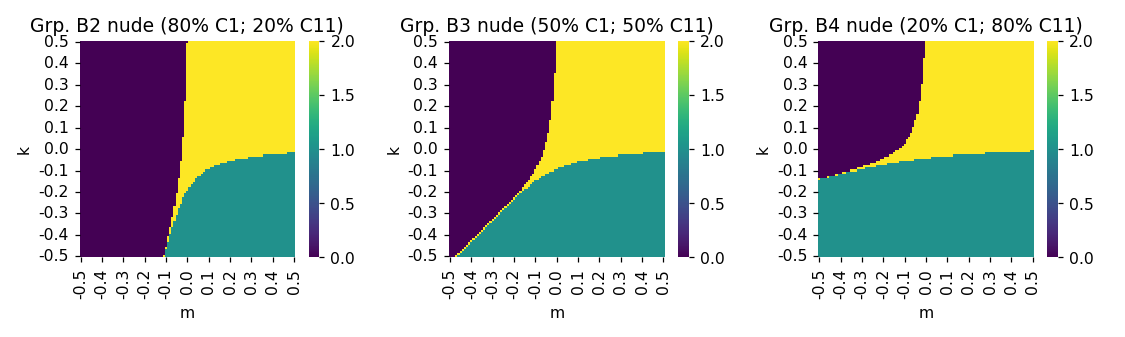

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
i = 0
for group in groups:
    group_df = results[results["group"]==group]
    hm_df = group_df.pivot(columns="m", index="k", values="end")
    hm_df = hm_df.sort_index(ascending=False)
    sns.heatmap(hm_df, cmap="viridis", ax=axes[i], yticklabels=list(map(round, hm_df.index, [2]*len(hm_df.index))), xticklabels=list(map(round, hm_df.columns, [2]*len(hm_df.columns))))
    axes[i].set_xticks(axes[i].get_xticks()[::10])
    axes[i].set_yticks(axes[i].get_yticks()[::10])
    # axes[i].axhline(.5*len(hm_df))
    # axes[i].axvline(.5*len(hm_df))
    axes[i].set_title(group)
    i += 1
plt.tight_layout()
if figure_save_path:
    plt.savefig(figure_save_path+"k_m_winner.svg")
plt.show()